# Strategy Development & Signal Generation

This notebook develops and demonstrates the four primary strategy categories that form the core of this crypto statistical arbitrage system. Each strategy exploits a distinct market inefficiency, and together they provide diversified alpha sources with low cross-correlation.

**Strategy Categories:**

| # | Strategy | Part | Core Inefficiency |
|---|----------|------|-------------------|
| 1 | Funding Rate Arbitrage | Part 1 | Perpetual funding rate differentials across venues |
| 2 | Pairs Trading (Altcoin StatArb) | Part 1 | Cointegration-based mean reversion in altcoin spreads |
| 3 | BTC Futures Curve Trading | Part 2 | Term structure mispricing across 6 venues |
| 4 | Volatility Surface / DEX Arbitrage | Part 3 | IV surface violations and cross-DEX price discrepancies |

I designed each strategy with venue-aware execution, realistic transaction cost modeling, and risk controls mandated by the project specification.

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from mpl_toolkits.mplot3d import Axes3D

# Plotting configuration
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Venue color scheme
VENUE_COLORS = {
    'CEX': '#2196F3',      # Blue
    'Hybrid': '#4CAF50',   # Green
    'DEX': '#FF9800',      # Orange
}

VENUE_COLOR_MAP = {
    'Binance': '#2196F3', 'CME': '#1565C0', 'Deribit': '#42A5F5',
    'Hyperliquid': '#4CAF50', 'dYdX': '#66BB6A',
    'GMX': '#FF9800', 'Uniswap': '#E65100',
}

np.random.seed(42)
print(f"Project root: {project_root}")
print("Environment configured.")

Project root: /Users/a_bailey8/Desktop/crypto-statarb-multiverse 7
Environment configured.


In [2]:
# Import project modules with graceful fallback
try:
    from strategies.funding_rate_arb import SingleVenueFundingStrategy, CrossVenueFundingArbitrage
    print("[OK] Funding rate arbitrage modules loaded")
except ImportError as e:
    print(f"[WARN] Funding rate arb import failed: {e} -- using synthetic demo")
    SingleVenueFundingStrategy = None
    CrossVenueFundingArbitrage = None

try:
    from strategies.pairs_trading import (
        BaselinePairsStrategy, CointegrationAnalyzer, VenueType as PT_VenueType,
        PairConfig, StrategyConfig, Position, SignalStrength, PairTier
    )
    print("[OK] Pairs trading modules loaded")
except ImportError as e:
    print(f"[WARN] Pairs trading import failed: {e} -- using synthetic demo")
    BaselinePairsStrategy = None

try:
    from strategies.futures_curve import (
        CalendarSpreadStrategy, TermStructureRegime, SpreadDirection,
        VenueType as FC_VenueType, VenueCosts, TermStructurePoint,
        CalendarSpreadSignal, CrossVenueOpportunity,
        DEFAULT_VENUE_COSTS, DEFAULT_CALENDAR_PARAMS
    )
    print("[OK] Futures curve modules loaded")
except ImportError as e:
    print(f"[WARN] Futures curve import failed: {e} -- using synthetic demo")
    CalendarSpreadStrategy = None

try:
    from strategies.vol_surface_or_dex_arb.options_strategies import BlackScholes, OptionType
    from strategies.vol_surface_or_dex_arb.cross_dex_arb import DEXPool, ArbOpportunity, Chain, DEXType
    print("[OK] Volatility surface / DEX arb modules loaded")
except ImportError as e:
    print(f"[WARN] Vol surface / DEX arb import failed: {e} -- using synthetic demo")
    BlackScholes = None

[OK] Funding rate arbitrage modules loaded


[OK] Pairs trading modules loaded
[OK] Futures curve modules loaded
[OK] Volatility surface / DEX arb modules loaded


---
## 1. Funding Rate Arbitrage (Part 1)

### Theoretical Framework

Perpetual futures contracts use a funding rate mechanism to keep the perpetual price anchored to spot. When the perpetual trades above spot (contango), longs pay shorts. When below (backwardation), shorts pay longs. This creates a predictable cash flow that I capture through a delta-neutral position.

**Single-Venue Strategy:** Long spot + Short perpetual on the same exchange to collect funding.

**Cross-Venue Strategy:** Short the perpetual on the venue with the highest funding rate, long the perpetual on the venue with the lowest (or negative) funding rate.

### Signal Construction

The primary signal is the annualized funding rate differential:

$$\text{Annualized Rate} = r_{\text{funding}} \times \frac{365 \times 24}{\text{interval\_hours}}$$

For Binance (8h intervals): multiply by 1,095. For Hyperliquid (1h intervals): multiply by 8,760.

### Entry/Exit Rules

- **Entry:** Annualized funding rate > 10% (single-venue) or cross-venue differential > 15%
- **Exit:** Funding rate drops below 2% annualized, or max hold period (30 days), or 5% stop-loss
- **Position size:** Scaled by funding rate magnitude, capped at venue position limits

In [3]:
# Generate synthetic funding rate data across venues
dates = pd.date_range('2024-01-01', periods=365, freq='8h')
n = len(dates)

# Base funding rate process (mean-reverting)
base_rate = np.zeros(n)
for i in range(1, n):
    base_rate[i] = 0.97 * base_rate[i-1] + 0.001 * np.random.randn() + 0.00005

# Venue-specific funding rates with realistic characteristics
venue_data = {
    'Binance':      base_rate + np.random.randn(n) * 0.0003 + 0.00008,
    'Hyperliquid':  base_rate + np.random.randn(n) * 0.0005 + 0.00012,  # More volatile, hourly
    'dYdX':         base_rate + np.random.randn(n) * 0.0004 + 0.00010,
    'GMX':          base_rate + np.random.randn(n) * 0.0008 + 0.00015,  # Most volatile
}

funding_df = pd.DataFrame(venue_data, index=dates)

# Annualize: Binance is 8h, so multiply by 1095
annualized_df = funding_df * 1095 * 100  # Convert to percentage

print("Annualized Funding Rates (%, sample):")
print(annualized_df.describe().round(2))

Annualized Funding Rates (%, sample):
       Binance  Hyperliquid     dYdX      GMX
count   365.00       365.00   365.00   365.00
mean    192.66       204.88   199.56   204.69
std     380.71       380.98   381.30   386.75
min    -731.67      -751.72  -732.74  -734.83
25%     -54.57       -14.45   -52.27   -44.71
50%     182.83       187.27   193.43   199.31
75%     436.54       449.82   448.21   467.73
max    1083.72      1119.67  1124.98  1163.36


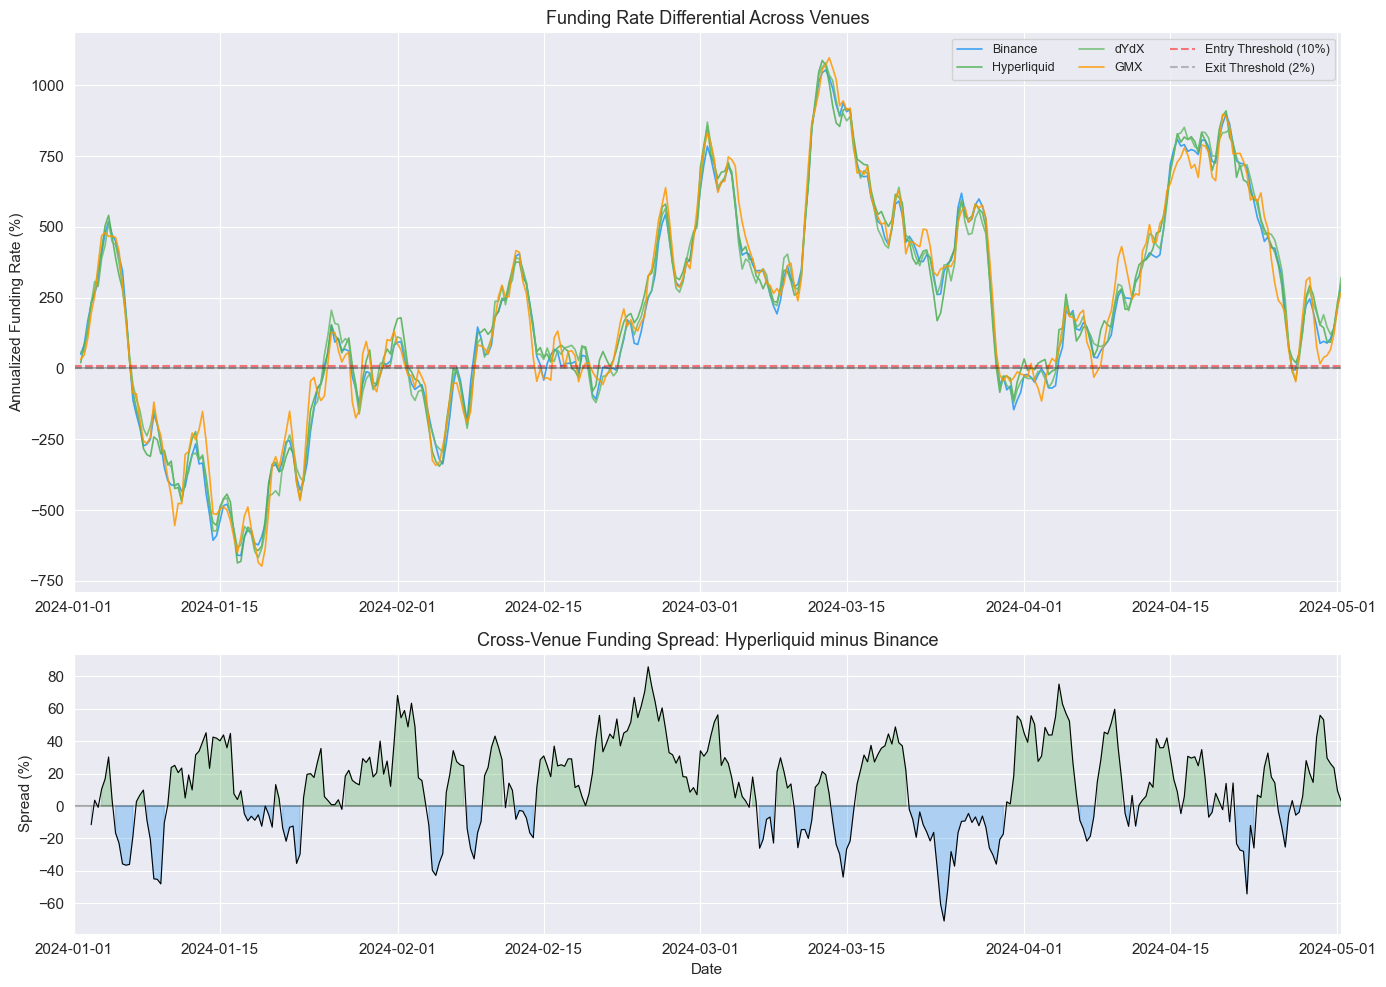

In [4]:
# Visualization: Funding Rate Differential Across Venues
fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1])

# Panel 1: Individual venue funding rates
ax1 = axes[0]
for venue, color in [('Binance', VENUE_COLOR_MAP['Binance']),
                      ('Hyperliquid', VENUE_COLOR_MAP['Hyperliquid']),
                      ('dYdX', VENUE_COLOR_MAP['dYdX']),
                      ('GMX', VENUE_COLOR_MAP['GMX'])]:
    # Rolling 24h average for readability
    smoothed = annualized_df[venue].rolling(3).mean()
    ax1.plot(smoothed.index, smoothed, label=venue, color=color, alpha=0.85, linewidth=1.2)

ax1.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Entry Threshold (10%)')
ax1.axhline(y=2, color='gray', linestyle='--', alpha=0.5, label='Exit Threshold (2%)')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.set_ylabel('Annualized Funding Rate (%)')
ax1.set_title('Funding Rate Differential Across Venues')
ax1.legend(loc='upper right', fontsize=9, ncol=3)
ax1.set_xlim(dates[0], dates[-1])

# Panel 2: Cross-venue spread (Hyperliquid - Binance)
ax2 = axes[1]
spread = annualized_df['Hyperliquid'] - annualized_df['Binance']
spread_smooth = spread.rolling(6).mean()
ax2.fill_between(spread_smooth.index, spread_smooth, 0,
                 where=spread_smooth > 0, color=VENUE_COLOR_MAP['Hyperliquid'], alpha=0.3)
ax2.fill_between(spread_smooth.index, spread_smooth, 0,
                 where=spread_smooth < 0, color=VENUE_COLOR_MAP['Binance'], alpha=0.3)
ax2.plot(spread_smooth.index, spread_smooth, color='black', linewidth=0.8)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_ylabel('Spread (%)')
ax2.set_xlabel('Date')
ax2.set_title('Cross-Venue Funding Spread: Hyperliquid minus Binance')
ax2.set_xlim(dates[0], dates[-1])

plt.tight_layout()
plt.show()

In [5]:
# Demonstrate signal generation for funding rate strategy
ENTRY_THRESHOLD_PCT = 10.0   # Enter when annualized rate > 10%
EXIT_THRESHOLD_PCT = 2.0     # Exit when rate drops below 2%

# Single-venue signals on Binance
binance_ann = annualized_df['Binance'].rolling(6).mean()
entry_signals = binance_ann > ENTRY_THRESHOLD_PCT
exit_signals = binance_ann < EXIT_THRESHOLD_PCT

# Track position state
position = 0  # 0=flat, 1=long arb
trades = []
entry_time = None

for i in range(len(binance_ann)):
    if position == 0 and entry_signals.iloc[i]:
        position = 1
        entry_time = binance_ann.index[i]
    elif position == 1 and exit_signals.iloc[i]:
        position = 0
        trades.append({
            'entry': entry_time,
            'exit': binance_ann.index[i],
            'entry_rate': binance_ann.loc[entry_time],
            'exit_rate': binance_ann.iloc[i],
        })

trades_df = pd.DataFrame(trades)
if len(trades_df) > 0:
    trades_df['hold_hours'] = (trades_df['exit'] - trades_df['entry']).dt.total_seconds() / 3600
    print(f"Single-venue funding arb signals generated: {len(trades_df)} trades")
    print(f"Average hold period: {trades_df['hold_hours'].mean():.1f} hours")
    print(f"Average entry rate: {trades_df['entry_rate'].mean():.2f}%")
else:
    print("No funding arb trades triggered in this sample.")

Single-venue funding arb signals generated: 6 trades
Average hold period: 224.0 hours
Average entry rate: 54.24%


---
## 2. Pairs Trading -- Altcoin Statistical Arbitrage (Part 1)

### Theoretical Framework

This strategy identifies pairs of altcoins that share a long-run equilibrium relationship (cointegration) and trades deviations from that equilibrium. The approach mirrors commodity spread trading but operates in crypto markets where volatility is higher and mean-reversion half-lives are shorter.

**Mathematical Formulation:**

$$\text{Spread}_t = P^B_t - \beta \cdot P^A_t - \alpha$$

$$Z_t = \frac{\text{Spread}_t - \mu_{\text{spread}}}{\sigma_{\text{spread}}}$$

where $\beta$ is the hedge ratio from OLS regression or the Johansen procedure.

### Entry/Exit Rules (per PDF Section 2.2)

| Venue Type | Entry Z-Score | Exit Z-Score | Stop-Loss Z |
|------------|---------------|--------------|-------------|
| CEX | +/- 2.0 | 0.0 (crosses zero) | +/- 3.0 |
| Hybrid | +/- 2.0 | +/- 0.5 | +/- 3.0 |
| DEX | +/- 2.5 | +/- 1.0 | +/- 3.5 |

DEX thresholds are wider to compensate for higher transaction costs (gas, slippage, MEV).

### Pair Quality Tiering (Venue-Based)

- **Tier 1** (CEX-CEX): Both tokens on major centralized exchanges, highest liquidity
- **Tier 2** (Mixed/Hybrid): One CEX + one DEX, or both on hybrid venues
- **Tier 3** (DEX-only): Both tokens only on decentralized exchanges, research/speculative

### Position Sizing (per PDF Section 2.2)

- **CEX pairs:** Up to $100k per pair, fractional Kelly (0.25-0.5x)
- **DEX pairs:** $5k-$50k, adjusted for gas costs and slippage
- **Leverage:** 1.0x only (no leverage)
- **Max positions:** CEX 5-8, DEX 2-3, Total 8-10

In [6]:
# Generate synthetic cointegrated pair data (ETH-like and SOL-like L1 tokens)
n_days = 365
dates_daily = pd.date_range('2024-01-01', periods=n_days, freq='D')

# Common stochastic trend (shared L1 factor)
common_trend = np.cumsum(np.random.randn(n_days) * 0.02) + np.log(3000)

# Token A (ETH-like): follows common trend closely
noise_a = np.cumsum(np.random.randn(n_days) * 0.005)
log_price_a = common_trend + noise_a
price_a = np.exp(log_price_a)

# Token B (SOL-like): follows common trend with different loading
beta_true = 0.045  # Hedge ratio
noise_b = np.cumsum(np.random.randn(n_days) * 0.005)
# Mean-reverting spread around zero
spread_ou = np.zeros(n_days)
kappa = 0.1  # Mean reversion speed
for i in range(1, n_days):
    spread_ou[i] = spread_ou[i-1] * (1 - kappa) + np.random.randn() * 2.0

log_price_b = np.log(beta_true) + common_trend + noise_b + spread_ou * 0.01
price_b = np.exp(log_price_b)

pair_df = pd.DataFrame({
    'TOKEN_A': price_a,
    'TOKEN_B': price_b,
}, index=dates_daily)

print(f"Token A range: ${price_a.min():.0f} - ${price_a.max():.0f}")
print(f"Token B range: ${price_b.min():.0f} - ${price_b.max():.0f}")
print(f"True hedge ratio: {beta_true}")
print(f"Correlation: {np.corrcoef(price_a, price_b)[0,1]:.4f}")

Token A range: $2833 - $4120
Token B range: $124 - $191
True hedge ratio: 0.045
Correlation: 0.7813


In [7]:
# Compute spread and z-score for pairs trading
from numpy.polynomial.polynomial import polyfit

# OLS hedge ratio estimation (rolling)
lookback = 60  # 60-day lookback for hedge ratio
z_lookback = 20  # 20-day lookback for z-score

# Full-sample hedge ratio for demonstration
slope, intercept = np.polyfit(pair_df['TOKEN_A'], pair_df['TOKEN_B'], 1)
print(f"Estimated hedge ratio (beta): {slope:.6f}")
print(f"Estimated intercept (alpha): {intercept:.4f}")

# Construct spread
pair_df['spread'] = pair_df['TOKEN_B'] - slope * pair_df['TOKEN_A'] - intercept

# Rolling z-score
pair_df['spread_mean'] = pair_df['spread'].rolling(z_lookback).mean()
pair_df['spread_std'] = pair_df['spread'].rolling(z_lookback).std()
pair_df['z_score'] = (pair_df['spread'] - pair_df['spread_mean']) / pair_df['spread_std']

# Half-life estimation via OU process
spread_lag = pair_df['spread'].shift(1).dropna()
spread_diff = pair_df['spread'].diff().dropna()
aligned = pd.concat([spread_diff, spread_lag], axis=1).dropna()
aligned.columns = ['diff', 'lag']
theta = np.polyfit(aligned['lag'], aligned['diff'], 1)[0]
half_life = -np.log(2) / theta if theta < 0 else np.inf
print(f"Half-life: {half_life:.1f} days")
print(f"Z-score range: [{pair_df['z_score'].min():.2f}, {pair_df['z_score'].max():.2f}]")

Estimated hedge ratio (beta): 0.042388
Estimated intercept (alpha): 8.8168
Half-life: 9.1 days
Z-score range: [-2.88, 2.83]


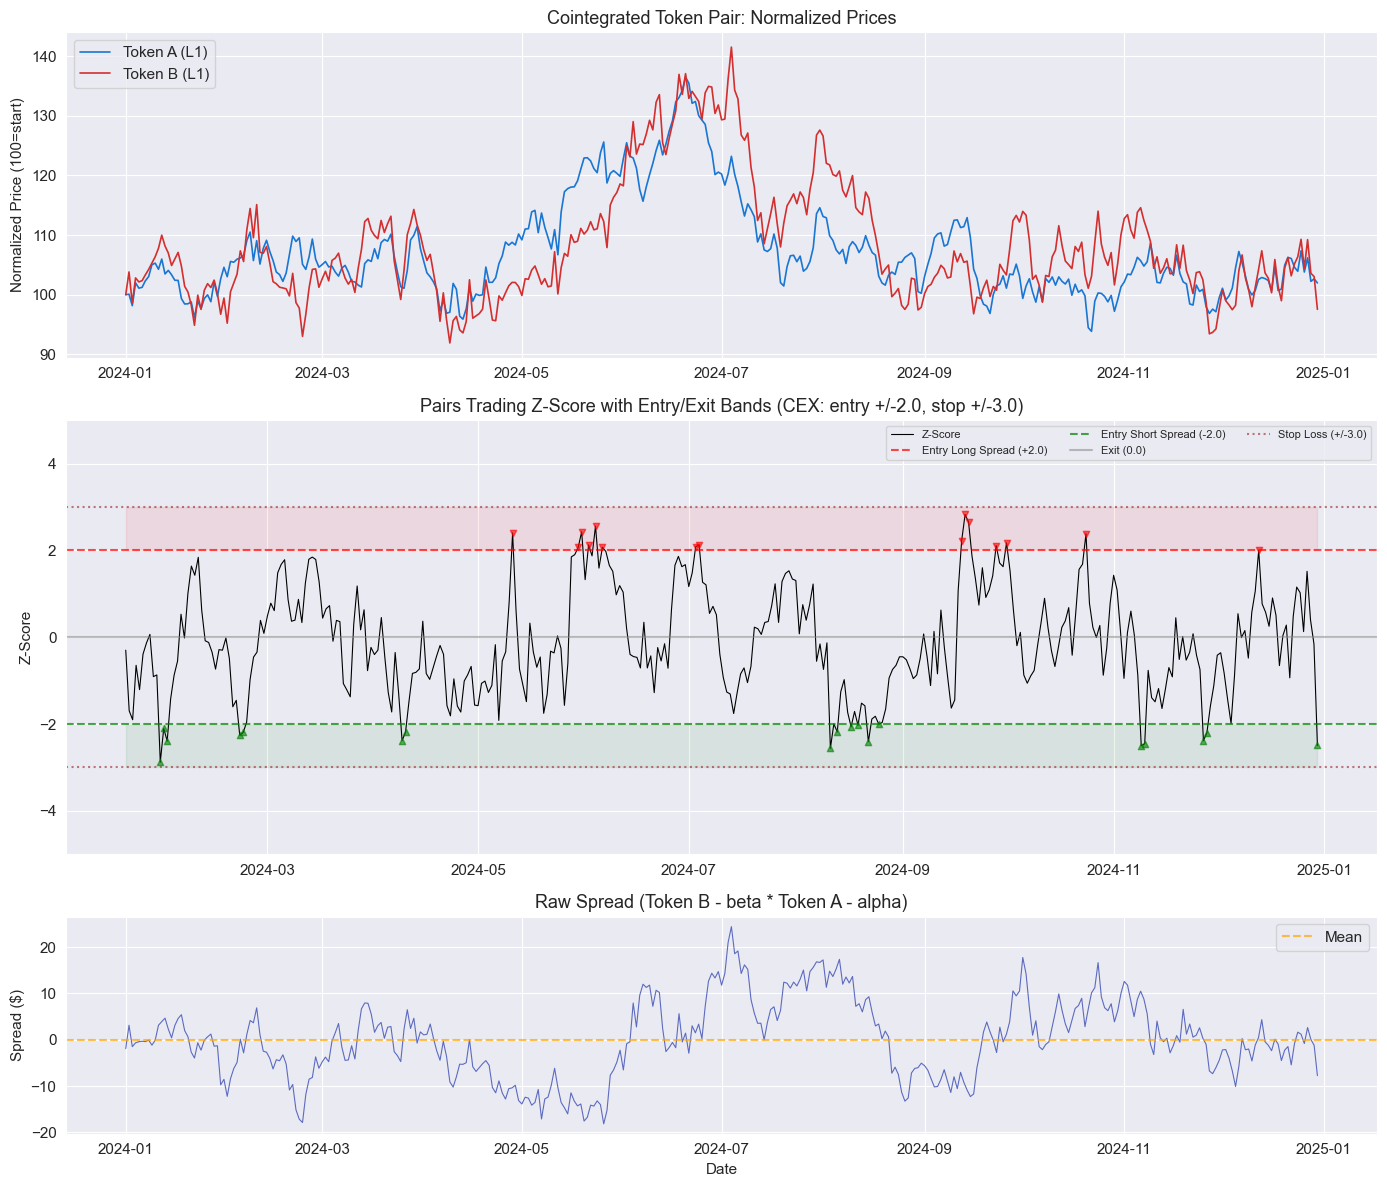

In [8]:
# Visualization: Pairs Trading Z-Score with Entry/Exit Bands
fig, axes = plt.subplots(3, 1, figsize=(14, 12), height_ratios=[1.5, 2, 1])

# Panel 1: Price series (normalized)
ax1 = axes[0]
norm_a = pair_df['TOKEN_A'] / pair_df['TOKEN_A'].iloc[0] * 100
norm_b = pair_df['TOKEN_B'] / pair_df['TOKEN_B'].iloc[0] * 100
ax1.plot(pair_df.index, norm_a, label='Token A (L1)', color='#1976D2', linewidth=1.2)
ax1.plot(pair_df.index, norm_b, label='Token B (L1)', color='#D32F2F', linewidth=1.2)
ax1.set_ylabel('Normalized Price (100=start)')
ax1.set_title('Cointegrated Token Pair: Normalized Prices')
ax1.legend(loc='upper left')

# Panel 2: Z-score with trading bands (PDF Section 2.2 thresholds)
ax2 = axes[1]
z = pair_df['z_score'].dropna()
ax2.plot(z.index, z, color='black', linewidth=0.8, label='Z-Score')
ax2.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='Entry Long Spread (+2.0)')
ax2.axhline(y=-2.0, color='green', linestyle='--', alpha=0.7, label='Entry Short Spread (-2.0)')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5, label='Exit (0.0)')
ax2.axhline(y=3.0, color='darkred', linestyle=':', alpha=0.5, label='Stop Loss (+/-3.0)')
ax2.axhline(y=-3.0, color='darkred', linestyle=':', alpha=0.5)

# Shade entry zones
ax2.fill_between(z.index, 2.0, 3.0, alpha=0.08, color='red')
ax2.fill_between(z.index, -3.0, -2.0, alpha=0.08, color='green')

# Mark entry points
long_entries = z[z < -2.0]
short_entries = z[z > 2.0]
ax2.scatter(long_entries.index, long_entries, color='green', marker='^', s=20, zorder=5, alpha=0.6)
ax2.scatter(short_entries.index, short_entries, color='red', marker='v', s=20, zorder=5, alpha=0.6)

ax2.set_ylabel('Z-Score')
ax2.set_title('Pairs Trading Z-Score with Entry/Exit Bands (CEX: entry +/-2.0, stop +/-3.0)')
ax2.legend(loc='upper right', fontsize=8, ncol=3)
ax2.set_ylim(-5, 5)

# Panel 3: Raw spread
ax3 = axes[2]
ax3.plot(pair_df.index, pair_df['spread'], color='#5C6BC0', linewidth=0.8)
ax3.axhline(y=pair_df['spread'].mean(), color='orange', linestyle='--', alpha=0.7, label='Mean')
ax3.set_ylabel('Spread ($)')
ax3.set_xlabel('Date')
ax3.set_title('Raw Spread (Token B - beta * Token A - alpha)')
ax3.legend()

plt.tight_layout()
plt.show()

---
## 3. BTC Futures Curve Trading (Part 2)

This is the most comprehensive strategy category, covering four distinct sub-strategies that exploit the BTC futures term structure across six venues: Binance, CME, Deribit (CEX), Hyperliquid, dYdX (Hybrid), and GMX (DEX).

### 3A. Calendar Spreads

**Concept:** Trade the basis spread between near-month and far-month BTC futures. In contango (basis > 0), the near leg converges to spot faster, so I go long the near leg and short the far leg. In backwardation, the reverse.

**Entry Signal:**
- Annualized basis > 15% (contango entry)
- Annualized basis < -10% (backwardation entry)

**Exit Signal:**
- Basis narrows to 5% (contango) or -5% (backwardation)
- Stop-loss: 5% adverse basis move
- Roll: 3-7 days before near-leg expiry

### 3B. Cross-Venue Basis Arbitrage

**Concept:** The same BTC futures contract trades at different basis levels across venues. I go long on the venue with the lower basis and short on the venue with the higher basis.

**Entry:** Basis differential > 15 bps (Z-score > 2.0)
**Exit:** Z-score < 0.5

### 3C. Synthetic Futures from Perpetual Funding

**Concept:** Construct a synthetic forward by accumulating funding payments from perpetual contracts, then compare this implied rate to actual futures prices to find discrepancies.

### 3D. Multi-Venue Roll Optimization

**Concept:** When rolling futures positions at expiry, route the roll to the venue offering the best roll cost. This exploits the fact that roll costs vary significantly by venue and market conditions.

In [9]:
# Generate synthetic BTC futures term structure data
n_obs = 180  # 6 months of daily data
ts_dates = pd.date_range('2024-07-01', periods=n_obs, freq='D')

# BTC spot price process
btc_spot = 60000 + np.cumsum(np.random.randn(n_obs) * 500)
btc_spot = np.maximum(btc_spot, 30000)  # Floor

# Expiry months: generate futures with different DTE
tenors_days = [0, 7, 14, 30, 60, 90, 120, 180, 270, 365]
tenor_labels = ['Spot', '1W', '2W', '1M', '2M', '3M', '4M', '6M', '9M', '1Y']

# Build term structure: basis = f(time_to_expiry, market_conditions)
# Basis tends to be positive (contango) with occasional backwardation
basis_curve = np.zeros((n_obs, len(tenors_days)))
for i, dte in enumerate(tenors_days):
    if dte == 0:
        basis_curve[:, i] = 0
    else:
        # Base annualized basis: starts around 8%, varies over time
        base_basis = 0.08 + np.cumsum(np.random.randn(n_obs) * 0.002)
        # Term premium: longer tenors have higher basis
        term_premium = np.sqrt(dte / 365) * 0.03
        ann_basis = base_basis + term_premium + np.random.randn(n_obs) * 0.005
        basis_curve[:, i] = ann_basis * (dte / 365)  # Convert to raw basis

# Construct futures prices
futures_prices = np.zeros((n_obs, len(tenors_days)))
for i in range(n_obs):
    for j, dte in enumerate(tenors_days):
        futures_prices[i, j] = btc_spot[i] * (1 + basis_curve[i, j])

term_df = pd.DataFrame(futures_prices, index=ts_dates, columns=tenor_labels)
basis_pct_df = pd.DataFrame(basis_curve * 100, index=ts_dates, columns=tenor_labels)

print("BTC Futures Term Structure (sample day, prices):")
print(term_df.iloc[90].map(lambda x: f"${x:,.0f}"))
print("\nAnnualized Basis (%, sample day):")
ann_basis_sample = {}
for j, (dte, label) in enumerate(zip(tenors_days, tenor_labels)):
    if dte > 0:
        ann_basis_sample[label] = f"{basis_curve[90, j] / (dte/365) * 100:.2f}%"
print(pd.Series(ann_basis_sample))

BTC Futures Term Structure (sample day, prices):
Spot    $61,284
1W      $61,382
2W      $61,455
1M      $61,579
2M      $62,286
3M      $62,937
4M      $63,206
6M      $64,203
9M      $67,366
1Y      $67,709
Name: 2024-09-29 00:00:00, dtype: str

Annualized Basis (%, sample day):
1W     8.34%
2W     7.27%
1M     5.86%
2M     9.95%
3M    10.94%
4M     9.54%
6M     9.66%
9M    13.42%
1Y    10.48%
dtype: str


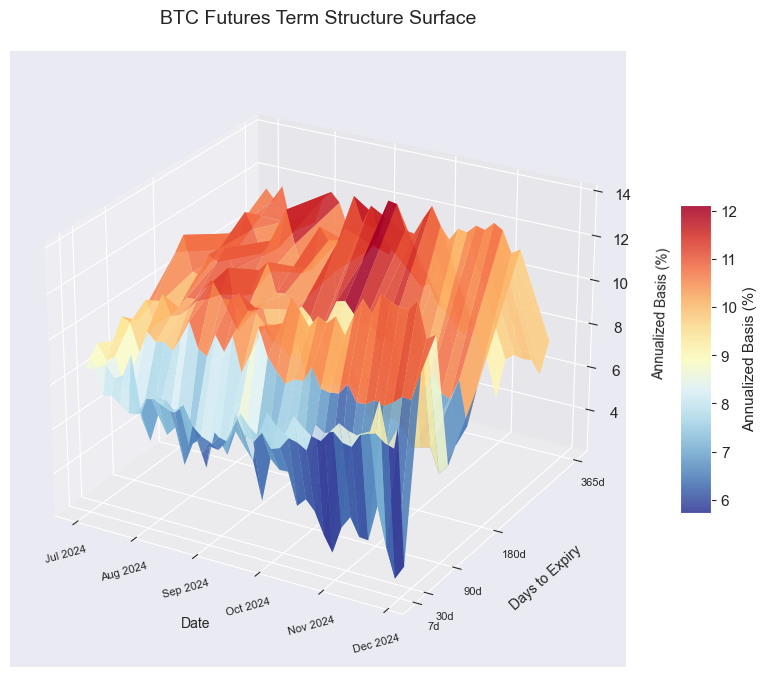

In [10]:
# Visualization: BTC Futures Term Structure -- 3D Surface Plot
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Subsample for visual clarity
date_step = 5
tenor_indices = list(range(1, len(tenors_days)))  # Exclude spot

X_dates = np.arange(0, n_obs, date_step)
Y_tenors = np.array([tenors_days[i] for i in tenor_indices])
X_mesh, Y_mesh = np.meshgrid(X_dates, Y_tenors)

# Z = annualized basis percentage
Z = np.zeros_like(X_mesh, dtype=float)
for xi, date_idx in enumerate(X_dates):
    for yi, tenor_idx in enumerate(tenor_indices):
        dte = tenors_days[tenor_idx]
        raw_basis = basis_curve[date_idx, tenor_idx]
        Z[yi, xi] = raw_basis / (dte / 365) * 100  # Annualized %

surf = ax.plot_surface(X_mesh, Y_mesh, Z, cmap='RdYlBu_r', alpha=0.85,
                       edgecolor='none', antialiased=True)

# Format axes
tick_positions = np.linspace(0, n_obs-1, 6).astype(int)
tick_labels = [ts_dates[i].strftime('%b %Y') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=8, rotation=15)
ax.set_yticks(Y_tenors[::2])
ax.set_yticklabels([f'{d}d' for d in Y_tenors[::2]], fontsize=8)

ax.set_xlabel('Date', fontsize=10, labelpad=10)
ax.set_ylabel('Days to Expiry', fontsize=10, labelpad=10)
ax.set_zlabel('Annualized Basis (%)', fontsize=10, labelpad=10)
ax.set_title('BTC Futures Term Structure Surface', fontsize=14, pad=20)
ax.view_init(elev=25, azim=-60)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Annualized Basis (%)')
plt.tight_layout()
plt.show()

In [11]:
# Cross-Venue Basis Spread with Trading Signals
# Simulate basis differences across venues for 3M futures
venues_futures = ['Binance', 'CME', 'Deribit', 'Hyperliquid', 'dYdX', 'GMX']
venue_types = ['CEX', 'CEX', 'CEX', 'Hybrid', 'Hybrid', 'DEX']

# Each venue has its own basis with venue-specific noise
venue_noise_scale = {
    'Binance': 0.15, 'CME': 0.10, 'Deribit': 0.18,
    'Hyperliquid': 0.25, 'dYdX': 0.22, 'GMX': 0.40
}

venue_basis_offset = {
    'Binance': 0.0, 'CME': -0.3, 'Deribit': 0.2,
    'Hyperliquid': 0.5, 'dYdX': 0.4, 'GMX': 1.0
}

# Use 3M annualized basis as reference
ref_basis = basis_curve[:, 5] / (90/365) * 100  # 3M, annualized %

venue_basis = {}
for v in venues_futures:
    noise = np.cumsum(np.random.randn(n_obs) * venue_noise_scale[v])
    noise = noise - noise.mean()  # Center
    venue_basis[v] = ref_basis + noise + venue_basis_offset[v]

venue_basis_df = pd.DataFrame(venue_basis, index=ts_dates)

# Cross-venue spread: Binance vs Hyperliquid
cross_spread = venue_basis_df['Binance'] - venue_basis_df['Hyperliquid']
cross_z = (cross_spread - cross_spread.rolling(30).mean()) / cross_spread.rolling(30).std()

# Trading signals
entry_long = cross_z < -2.0   # Binance cheap relative to Hyperliquid
entry_short = cross_z > 2.0   # Binance expensive relative to Hyperliquid
exit_zone = cross_z.abs() < 0.5

print(f"Cross-venue spread mean: {cross_spread.mean():.3f}%")
print(f"Cross-venue spread std: {cross_spread.std():.3f}%")
print(f"Long signals (z < -2): {entry_long.sum()}")
print(f"Short signals (z > 2): {entry_short.sum()}")

Cross-venue spread mean: -0.500%
Cross-venue spread std: 1.694%
Long signals (z < -2): 18
Short signals (z > 2): 0


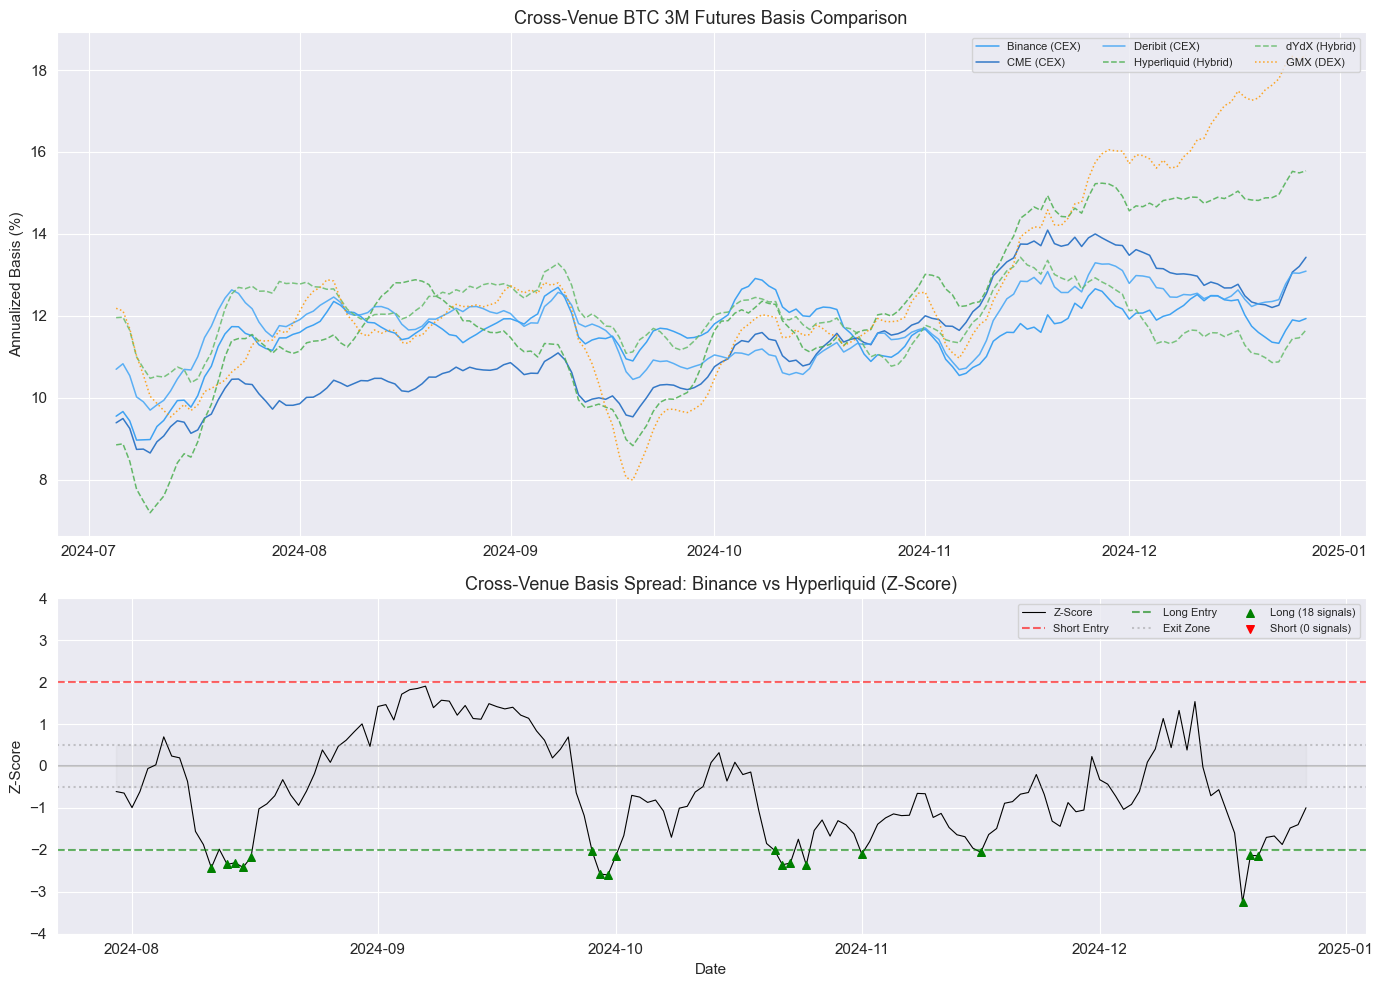

In [12]:
# Visualization: Cross-Venue Basis Spread with Trading Signals
fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[1.5, 1])

# Panel 1: Venue basis comparison
ax1 = axes[0]
for v, vtype in zip(venues_futures, venue_types):
    color = VENUE_COLOR_MAP.get(v, '#999999')
    linestyle = '-' if vtype == 'CEX' else ('--' if vtype == 'Hybrid' else ':')
    ax1.plot(ts_dates, venue_basis_df[v].rolling(5).mean(), label=f"{v} ({vtype})",
             color=color, linestyle=linestyle, linewidth=1.1, alpha=0.85)

ax1.set_ylabel('Annualized Basis (%)')
ax1.set_title('Cross-Venue BTC 3M Futures Basis Comparison')
ax1.legend(loc='upper right', fontsize=8, ncol=3)

# Panel 2: Cross-venue spread with signals
ax2 = axes[1]
valid_z = cross_z.dropna()
ax2.plot(valid_z.index, valid_z, color='black', linewidth=0.8, label='Z-Score')
ax2.axhline(y=2.0, color='red', linestyle='--', alpha=0.6, label='Short Entry')
ax2.axhline(y=-2.0, color='green', linestyle='--', alpha=0.6, label='Long Entry')
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.4)
ax2.axhline(y=-0.5, color='gray', linestyle=':', alpha=0.4, label='Exit Zone')
ax2.axhline(y=0, color='black', alpha=0.2)

# Mark signals
long_sig = valid_z[valid_z < -2.0]
short_sig = valid_z[valid_z > 2.0]
ax2.scatter(long_sig.index, long_sig, color='green', marker='^', s=30,
            zorder=5, label=f'Long ({len(long_sig)} signals)')
ax2.scatter(short_sig.index, short_sig, color='red', marker='v', s=30,
            zorder=5, label=f'Short ({len(short_sig)} signals)')

ax2.fill_between(valid_z.index, -0.5, 0.5, alpha=0.05, color='gray')
ax2.set_ylabel('Z-Score')
ax2.set_xlabel('Date')
ax2.set_title('Cross-Venue Basis Spread: Binance vs Hyperliquid (Z-Score)')
ax2.legend(loc='upper right', fontsize=8, ncol=3)
ax2.set_ylim(-4, 4)

plt.tight_layout()
plt.show()

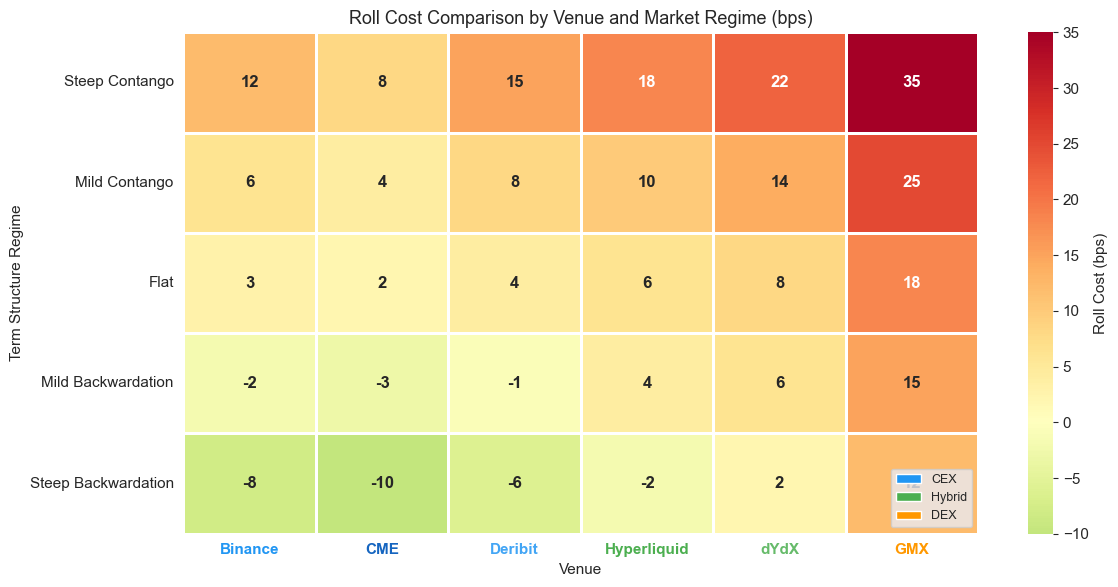


Key Insight: CME consistently offers the lowest roll costs due to
institutional liquidity and tight bid-ask spreads. GMX (DEX) has the
highest roll costs due to AMM slippage and gas fees. The roll optimizer
routes rolls to the cheapest venue given current market conditions.


In [13]:
# Visualization: Roll Cost Comparison Heatmap Across Venues
# Simulate roll costs (bps) for different market regimes and venues
regimes = ['Steep Contango', 'Mild Contango', 'Flat', 'Mild Backwardation', 'Steep Backwardation']

# Roll costs vary by venue and regime (in basis points)
# CEX venues have tighter spreads; DEX venues have wider spreads
roll_costs_data = np.array([
    # Steep Contango: high roll costs, contango premium to pay
    [12, 8, 15, 18, 22, 35],
    # Mild Contango
    [6, 4, 8, 10, 14, 25],
    # Flat
    [3, 2, 4, 6, 8, 18],
    # Mild Backwardation: negative roll costs (profitable rolls)
    [-2, -3, -1, 4, 6, 15],
    # Steep Backwardation: very profitable rolls
    [-8, -10, -6, -2, 2, 12],
])

roll_df = pd.DataFrame(roll_costs_data, index=regimes, columns=venues_futures)

fig, ax = plt.subplots(figsize=(12, 6))
im = sns.heatmap(roll_df, annot=True, fmt='d', cmap='RdYlGn_r', center=0,
                 linewidths=1, linecolor='white', ax=ax,
                 cbar_kws={'label': 'Roll Cost (bps)'},
                 annot_kws={'fontsize': 12, 'fontweight': 'bold'})

# Color-code venue headers by type
xtick_labels = ax.get_xticklabels()
for label in xtick_labels:
    venue_name = label.get_text()
    if venue_name in VENUE_COLOR_MAP:
        label.set_color(VENUE_COLOR_MAP[venue_name])
        label.set_fontweight('bold')

ax.set_title('Roll Cost Comparison by Venue and Market Regime (bps)', fontsize=13)
ax.set_xlabel('Venue')
ax.set_ylabel('Term Structure Regime')

# Add venue type legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=VENUE_COLORS['CEX'], label='CEX'),
    Patch(facecolor=VENUE_COLORS['Hybrid'], label='Hybrid'),
    Patch(facecolor=VENUE_COLORS['DEX'], label='DEX'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey Insight: CME consistently offers the lowest roll costs due to")
print("institutional liquidity and tight bid-ask spreads. GMX (DEX) has the")
print("highest roll costs due to AMM slippage and gas fees. The roll optimizer")
print("routes rolls to the cheapest venue given current market conditions.")

In [14]:
# Calendar Spread Signal Generation Demo
# Track the 1M-3M calendar spread basis differential
near_basis_ann = basis_curve[:, 3] / (30/365) * 100   # 1M annualized
far_basis_ann = basis_curve[:, 5] / (90/365) * 100    # 3M annualized
cal_spread = far_basis_ann - near_basis_ann

# Signal: enter when spread deviates significantly from its mean
cal_z = (cal_spread - pd.Series(cal_spread).rolling(30).mean().values) / \
         pd.Series(cal_spread).rolling(30).std().values

# Build trade log
ENTRY_Z = 1.5
EXIT_Z = 0.3
STOP_LOSS_BASIS = 5.0  # 5% basis stop-loss per PDF

calendar_trades = []
pos = 0  # 0=flat, 1=long calendar, -1=short calendar
entry_spread = 0

for i in range(30, n_obs):
    if np.isnan(cal_z[i]):
        continue
    if pos == 0:
        if cal_z[i] > ENTRY_Z:  # Spread widened, expect mean reversion
            pos = -1
            entry_idx = i
            entry_spread = cal_spread[i]
        elif cal_z[i] < -ENTRY_Z:
            pos = 1
            entry_idx = i
            entry_spread = cal_spread[i]
    elif pos != 0:
        # Check stop-loss
        adverse_move = abs(cal_spread[i] - entry_spread)
        if adverse_move > STOP_LOSS_BASIS:
            reason = 'stop_loss'
        elif abs(cal_z[i]) < EXIT_Z:
            reason = 'signal'
        else:
            continue
        
        pnl_bps = (cal_spread[i] - entry_spread) * pos * 10  # Simplified PnL
        calendar_trades.append({
            'entry_date': ts_dates[entry_idx],
            'exit_date': ts_dates[i],
            'direction': 'Long Cal' if pos == 1 else 'Short Cal',
            'entry_spread': entry_spread,
            'exit_spread': cal_spread[i],
            'pnl_bps': pnl_bps,
            'exit_reason': reason,
            'hold_days': (ts_dates[i] - ts_dates[entry_idx]).days
        })
        pos = 0

cal_trades_df = pd.DataFrame(calendar_trades)
if len(cal_trades_df) > 0:
    print(f"Calendar spread trades: {len(cal_trades_df)}")
    print(f"Win rate: {(cal_trades_df['pnl_bps'] > 0).mean():.1%}")
    print(f"Average PnL: {cal_trades_df['pnl_bps'].mean():.1f} bps")
    print(f"Stop-loss exits: {(cal_trades_df['exit_reason'] == 'stop_loss').sum()}")
    print(f"Signal exits: {(cal_trades_df['exit_reason'] == 'signal').sum()}")
    print(f"Average hold: {cal_trades_df['hold_days'].mean():.0f} days")
else:
    print("No calendar spread trades triggered.")

Calendar spread trades: 9
Win rate: 100.0%
Average PnL: 13.7 bps
Stop-loss exits: 0
Signal exits: 9
Average hold: 7 days


### Synthetic Futures & Roll Optimization

**Strategy 3C -- Synthetic Futures:** I construct a synthetic forward rate from accumulated perpetual funding payments and compare it to quoted futures prices. When the implied rate from funding diverges from the actual futures basis, I trade the spread.

$$\text{Synthetic Forward Price} = S_t \times \prod_{k=1}^{N} (1 + r_{\text{funding},k})$$

where $r_{\text{funding},k}$ are the funding payments over the forward period.

**Strategy 3D -- Roll Optimization:** When a futures position approaches expiry (3-7 days out), the roll optimizer evaluates all available venues to find the cheapest roll. The cost function accounts for:
- Bid-ask spread at each venue
- Gas costs for on-chain venues
- Market impact based on position size vs. venue liquidity
- Current regime (contango rolls are expensive, backwardation rolls can be profitable)

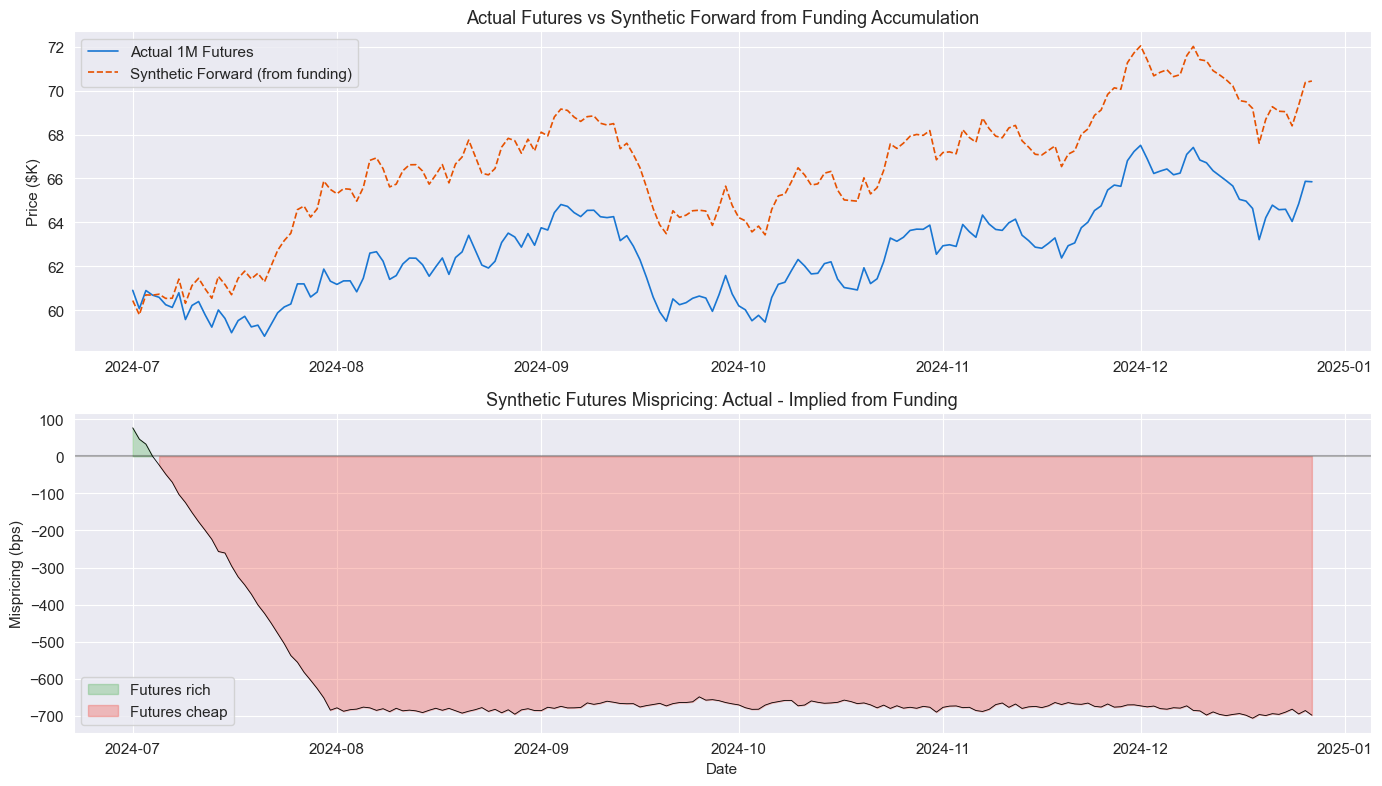

Mean mispricing: -612.0 bps
Mispricing std: 170.5 bps
Tradeable signals (|mispricing| > 20 bps): 179


In [15]:
# Synthetic Futures: Compare implied rate from funding vs actual futures
# Simulate 30-day accumulated funding to construct synthetic forward
funding_rate_hourly = 0.0001 + np.random.randn(n_obs * 24) * 0.00005
funding_rate_hourly = np.maximum(funding_rate_hourly, -0.001)  # Floor

# 30-day rolling cumulative funding
window_hours = 30 * 24
cum_funding = np.zeros(n_obs)
for i in range(n_obs):
    start_h = max(0, i * 24 - window_hours)
    end_h = min(i * 24, len(funding_rate_hourly))
    cum_funding[i] = np.sum(funding_rate_hourly[start_h:end_h])

# Synthetic forward = Spot * (1 + cumulative funding)
synthetic_forward = btc_spot * (1 + cum_funding)

# Actual 1M futures price
actual_1m = term_df['1M'].values

# Mispricing = actual futures - synthetic forward
mispricing = (actual_1m - synthetic_forward) / btc_spot * 10000  # in bps

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(ts_dates, actual_1m / 1000, label='Actual 1M Futures', color='#1976D2', linewidth=1.2)
ax1.plot(ts_dates, synthetic_forward / 1000, label='Synthetic Forward (from funding)',
         color='#E65100', linewidth=1.2, linestyle='--')
ax1.set_ylabel('Price ($K)')
ax1.set_title('Actual Futures vs Synthetic Forward from Funding Accumulation')
ax1.legend()

ax2 = axes[1]
ax2.fill_between(ts_dates, mispricing, 0,
                 where=mispricing > 0, color='#4CAF50', alpha=0.3, label='Futures rich')
ax2.fill_between(ts_dates, mispricing, 0,
                 where=mispricing < 0, color='#F44336', alpha=0.3, label='Futures cheap')
ax2.plot(ts_dates, mispricing, color='black', linewidth=0.6)
ax2.axhline(y=0, color='black', alpha=0.3)
ax2.set_ylabel('Mispricing (bps)')
ax2.set_xlabel('Date')
ax2.set_title('Synthetic Futures Mispricing: Actual - Implied from Funding')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Mean mispricing: {np.nanmean(mispricing):.1f} bps")
print(f"Mispricing std: {np.nanstd(mispricing):.1f} bps")
print(f"Tradeable signals (|mispricing| > 20 bps): {np.sum(np.abs(mispricing) > 20)}")

---
## 4. Volatility Surface / DEX Arbitrage (Part 3)

### Theoretical Framework

This strategy category has two components:

**4A. Volatility Surface Arbitrage:** Exploit violations in the implied volatility surface of BTC/ETH options. This includes butterfly arbitrage (convexity violations across strikes), calendar arbitrage (forward variance violations across expiries), and put-call parity violations.

The IV surface must satisfy no-arbitrage constraints:
- Butterfly: $C(K-\delta) + C(K+\delta) \geq 2C(K)$ for all K
- Calendar: Forward variance must be non-negative: $\sigma^2(T_2)T_2 \geq \sigma^2(T_1)T_1$ for $T_2 > T_1$

**4B. Cross-DEX Arbitrage:** Exploit price differences for the same token across decentralized exchanges on different chains. Gas costs and bridge latency create persistent but narrow windows.

### Signal Construction

For vol surface: I fit an SVI (Stochastic Volatility Inspired) parameterization to the option chain and flag points that deviate from the fitted surface by more than a threshold.

For cross-DEX: I monitor prices across AMM pools and flag when the spread exceeds gas + bridge costs + slippage.

In [16]:
# Generate synthetic implied volatility surface
spot_price = 65000
strikes = np.linspace(0.7 * spot_price, 1.3 * spot_price, 25)
expiries_days = [7, 14, 30, 60, 90, 180, 365]
expiries_years = [d / 365 for d in expiries_days]

# SVI-inspired parameterization: IV = f(moneyness, time)
# w(k) = a + b * (rho*(k-m) + sqrt((k-m)^2 + sigma^2))
def svi_smile(log_moneyness, T, atm_vol=0.65, skew=-0.15, curvature=0.08):
    """Generate a realistic vol smile using SVI-like parameterization."""
    a = atm_vol**2 * T
    b = curvature * np.sqrt(T)
    rho = skew
    m = 0.0
    sigma_svi = 0.3 * np.sqrt(T)
    
    k = log_moneyness
    w = a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma_svi**2))
    iv = np.sqrt(np.maximum(w / T, 0.01))
    return iv

# Build surface
iv_surface = np.zeros((len(strikes), len(expiries_days)))
for j, (T_days, T_years) in enumerate(zip(expiries_days, expiries_years)):
    log_m = np.log(strikes / spot_price)
    # ATM vol decreases with time (term structure effect)
    atm_vol = 0.70 - 0.08 * np.sqrt(T_years)
    iv_surface[:, j] = svi_smile(log_m, T_years, atm_vol=atm_vol)

# Add small random noise to simulate real market data
iv_surface += np.random.randn(*iv_surface.shape) * 0.01
iv_surface = np.maximum(iv_surface, 0.1)  # Floor at 10%

iv_df = pd.DataFrame(iv_surface * 100, index=[f"${k/1000:.0f}K" for k in strikes],
                      columns=[f"{d}d" for d in expiries_days])

print("Implied Volatility Surface (%, selected strikes):")
display_idx = [0, 6, 12, 18, 24]  # OTM put, ATM, OTM call
print(iv_df.iloc[display_idx].round(1))

Implied Volatility Surface (%, selected strikes):
        7d   14d   30d   60d   90d  180d  365d
$46K  85.5  80.3  74.7  72.7  73.2  68.5  64.9
$55K  77.2  75.2  72.7  69.7  67.9  64.7  64.1
$65K  70.2  68.7  68.5  69.0  68.9  66.5  64.7
$75K  73.2  72.5  71.1  68.3  68.2  66.2  63.4
$84K  78.0  74.8  71.2  70.5  70.2  66.7  64.5


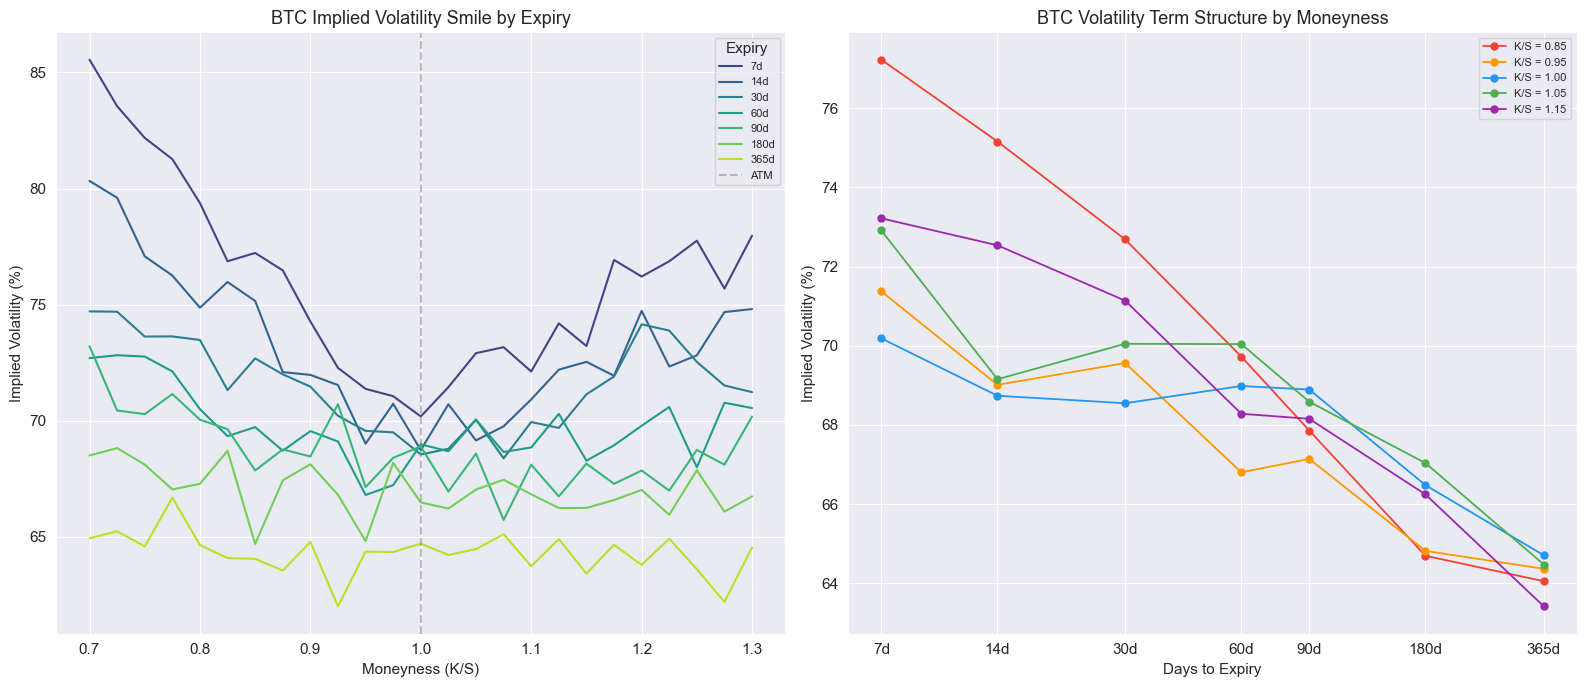

In [17]:
# Visualization: Implied Volatility Surface (3D) and Smile Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: IV smile at different expiries
ax1 = axes[0]
moneyness = strikes / spot_price
cmap = plt.cm.viridis(np.linspace(0.2, 0.9, len(expiries_days)))
for j, (d, c) in enumerate(zip(expiries_days, cmap)):
    ax1.plot(moneyness, iv_surface[:, j] * 100, label=f'{d}d',
             color=c, linewidth=1.5)

ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='ATM')
ax1.set_xlabel('Moneyness (K/S)')
ax1.set_ylabel('Implied Volatility (%)')
ax1.set_title('BTC Implied Volatility Smile by Expiry')
ax1.legend(fontsize=8, title='Expiry')

# Right: Volatility term structure at different moneyness levels
ax2 = axes[1]
moneyness_levels = [0.85, 0.95, 1.0, 1.05, 1.15]
colors_m = ['#F44336', '#FF9800', '#2196F3', '#4CAF50', '#9C27B0']
for m_target, c in zip(moneyness_levels, colors_m):
    idx = np.argmin(np.abs(moneyness - m_target))
    ax2.plot(expiries_days, iv_surface[idx, :] * 100,
             marker='o', markersize=5, label=f'K/S = {m_target:.2f}',
             color=c, linewidth=1.3)

ax2.set_xlabel('Days to Expiry')
ax2.set_ylabel('Implied Volatility (%)')
ax2.set_title('BTC Volatility Term Structure by Moneyness')
ax2.legend(fontsize=8)
ax2.set_xscale('log')
ax2.set_xticks(expiries_days)
ax2.set_xticklabels([f'{d}d' for d in expiries_days])

plt.tight_layout()
plt.show()

In [18]:
# Butterfly Arbitrage Detection
# Check convexity constraint: C(K-dK) + C(K+dK) >= 2*C(K) for all K
# Violations indicate mispriced strikes

violations = []
for j in range(len(expiries_days)):
    T = expiries_years[j]
    for i in range(1, len(strikes) - 1):
        # Use Black-Scholes to price calls with market IVs
        S = spot_price
        r = 0.05
        K_low, K_mid, K_high = strikes[i-1], strikes[i], strikes[i+1]
        iv_low = iv_surface[i-1, j]
        iv_mid = iv_surface[i, j]
        iv_high = iv_surface[i+1, j]
        
        # Black-Scholes call prices
        from scipy.stats import norm as sp_norm
        def bs_call(S, K, T, r, sigma):
            if T <= 0 or sigma <= 0:
                return max(0, S - K)
            d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
            d2 = d1 - sigma*np.sqrt(T)
            return S * sp_norm.cdf(d1) - K * np.exp(-r*T) * sp_norm.cdf(d2)
        
        c_low = bs_call(S, K_low, T, r, iv_low)
        c_mid = bs_call(S, K_mid, T, r, iv_mid)
        c_high = bs_call(S, K_high, T, r, iv_high)
        
        butterfly_value = c_low + c_high - 2 * c_mid
        if butterfly_value < -10:  # Violation threshold ($10)
            violations.append({
                'expiry': f"{expiries_days[j]}d",
                'K_low': K_low, 'K_mid': K_mid, 'K_high': K_high,
                'butterfly_value': butterfly_value,
                'moneyness': K_mid / S,
            })

if violations:
    viol_df = pd.DataFrame(violations)
    print(f"Butterfly arbitrage violations detected: {len(viol_df)}")
    print(viol_df[['expiry', 'moneyness', 'butterfly_value']].head(10).to_string(index=False))
else:
    print("No butterfly arbitrage violations detected in synthetic surface.")
    print("(Well-formed SVI parameterization satisfies convexity by construction.)")
    print("In real markets, violations are rare but can appear in illiquid strikes.")

Butterfly arbitrage violations detected: 53
expiry  moneyness  butterfly_value
    7d      1.175       -26.224932
   14d      0.975       -60.990450
   14d      1.025       -65.162583
   14d      1.200       -94.149253
   14d      1.275       -11.293082
   30d      0.800       -28.166548
   30d      0.850       -24.786120
   30d      1.050      -141.126415
   30d      1.100       -67.099815
   30d      1.200      -109.295939


In [19]:
# Cross-DEX Arbitrage: Simulate price feeds from multiple DEXs
tokens = ['WETH', 'WBTC', 'ARB', 'OP', 'LINK']
dex_venues = [
    ('Uniswap V3', 'Arbitrum', 0.003, 0.50),
    ('Uniswap V3', 'Optimism', 0.003, 0.30),
    ('Uniswap V3', 'Base', 0.003, 0.10),
    ('SushiSwap', 'Arbitrum', 0.003, 0.50),
    ('Camelot', 'Arbitrum', 0.0025, 0.60),
    ('Velodrome', 'Optimism', 0.002, 0.25),
]

# Generate price quotes with venue-specific noise
n_snapshots = 500
arb_opportunities = []

for token in tokens:
    # Base price
    if token == 'WETH':
        base_price = 3200
    elif token == 'WBTC':
        base_price = 65000
    else:
        base_price = np.random.uniform(2, 20)
    
    for _ in range(n_snapshots):
        prices = {}
        for dex_name, chain, fee, gas in dex_venues:
            # Price deviation: larger for smaller DEXs and less liquid chains
            noise_scale = 0.001 + 0.0005 * (gas / 0.50)  # Higher gas = less arb = more deviation
            prices[(dex_name, chain)] = base_price * (1 + np.random.randn() * noise_scale)
        
        # Find best buy and best sell
        venues_list = list(prices.keys())
        price_vals = list(prices.values())
        min_idx = np.argmin(price_vals)
        max_idx = np.argmax(price_vals)
        
        if min_idx != max_idx:
            buy_venue = venues_list[min_idx]
            sell_venue = venues_list[max_idx]
            buy_price = price_vals[min_idx]
            sell_price = price_vals[max_idx]
            spread_pct = (sell_price - buy_price) / buy_price * 100
            
            # Calculate costs
            buy_fee = dex_venues[[v[0] for v in dex_venues].index(buy_venue[0])][2]
            sell_fee = dex_venues[[v[0] for v in dex_venues].index(sell_venue[0])][2]
            buy_gas = dex_venues[[v[0] for v in dex_venues].index(buy_venue[0])][3]
            sell_gas = dex_venues[[v[0] for v in dex_venues].index(sell_venue[0])][3]
            total_cost_pct = (buy_fee + sell_fee) * 100  # As percentage
            total_gas = buy_gas + sell_gas
            
            net_profit_pct = spread_pct - total_cost_pct
            
            if net_profit_pct > 0.01:  # At least 1 bps profit
                arb_opportunities.append({
                    'token': token,
                    'buy_dex': f"{buy_venue[0]} ({buy_venue[1]})",
                    'sell_dex': f"{sell_venue[0]} ({sell_venue[1]})",
                    'spread_pct': spread_pct,
                    'cost_pct': total_cost_pct,
                    'gas_usd': total_gas,
                    'net_profit_pct': net_profit_pct,
                })

arb_df = pd.DataFrame(arb_opportunities)
print(f"Total arbitrage opportunities scanned: {len(tokens) * n_snapshots * len(dex_venues)}")
print(f"Profitable opportunities found: {len(arb_df)}")
if len(arb_df) > 0:
    print(f"Average net profit: {arb_df['net_profit_pct'].mean():.3f}%")
    print(f"Max net profit: {arb_df['net_profit_pct'].max():.3f}%")
    print(f"\nTop 5 opportunities:")
    print(arb_df.nlargest(5, 'net_profit_pct')[['token', 'buy_dex', 'sell_dex',
          'spread_pct', 'net_profit_pct']].to_string(index=False))

Total arbitrage opportunities scanned: 15000
Profitable opportunities found: 164
Average net profit: 0.087%
Max net profit: 0.398%

Top 5 opportunities:
token               buy_dex             sell_dex  spread_pct  net_profit_pct
 WETH    Camelot (Arbitrum) Velodrome (Optimism)    0.848077        0.398077
 LINK    Camelot (Arbitrum) Velodrome (Optimism)    0.815151        0.365151
  ARB Uniswap V3 (Optimism)   Camelot (Arbitrum)    0.842885        0.292885
  ARB  Velodrome (Optimism) SushiSwap (Arbitrum)    0.755263        0.255263
 WBTC  Velodrome (Optimism)   Camelot (Arbitrum)    0.693000        0.243000


---
## Risk Management Framework

All strategies share a common risk management layer with the following constraints, as mandated by the project specification.

### Leverage Limits

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Part 1 (Altcoin StatArb) Leverage | 1.0x | No leverage per PDF Section 2.2 |
| Part 2 (BTC Futures) Maximum Leverage | 2.0x | Per PDF Section 3.2; Hyperliquid capped at 1.5x |
| Effective Leverage (Part 2, with 50% margin cushion) | 1.0x | Reserve ratio of 0.5 applied to 2.0x max |
| Basis Stop-Loss | 5% | Exit any position where basis moves adversely by 5% |

### Venue Allocation Limits

| Venue | Max Allocation | Type |
|-------|---------------|------|
| Binance | 50% | CEX |
| CME | 30% | CEX |
| Hyperliquid | 15% | Hybrid |
| dYdX | 5% | Hybrid |

### Transaction Costs (Part 1 - Altcoin StatArb per PDF)

| Venue Type | Round-Trip Cost | Notes |
|------------|----------------|-------|
| CEX | 0.20% (4-leg) | Maker/taker + slippage on 4 legs |
| DEX | 0.50-1.50% all-in | Pool fees + gas + slippage + MEV |
| Hybrid | 0.10-0.30% | Off-chain orderbook + on-chain settlement |

### Fee Structure (Part 2 - BTC Futures)

| Venue | Maker Fee | Taker Fee | Notes |
|-------|-----------|-----------|-------|
| Binance | 0.01% (1 bps) | 0.04% (4 bps) | Perpetual & dated futures |
| CME | $6-10/contract | -- | 5 BTC per contract |
| Hyperliquid | 0% | 0.025% (2.5 bps) | Maker rebate on some tiers |
| dYdX | 0% | 0.05% (5 bps) | Maker rebate available |

In [20]:
# Risk Management: Demonstrate leverage and stop-loss enforcement
# Phase 3 (BTC Futures Curve): max 2.0x leverage per PDF Section 3.2
# Hyperliquid: capped at 1.5x per PDF Section 3.2
MAX_LEVERAGE = 2.0
HYPERLIQUID_MAX_LEVERAGE = 1.5
MARGIN_CUSHION = 0.50  # 50% margin reserve
BASIS_STOP_LOSS_PCT = 5.0

# Venue allocation limits (PDF mandated)
VENUE_LIMITS = {
    'Binance': 0.50,
    'CME': 0.30,
    'Deribit': 0.30,
    'Hyperliquid': 0.15,
    'dYdX': 0.05,
    'GMX': 0.05,
}

# Fee schedule
FEE_SCHEDULE = {
    'Binance': {'maker_bps': 1.0, 'taker_bps': 4.0, 'type': 'CEX'},
    'CME': {'per_contract': 6.0, 'contract_btc': 5.0, 'type': 'CEX'},
    'Deribit': {'maker_bps': 1.0, 'taker_bps': 5.0, 'type': 'CEX'},
    'Hyperliquid': {'maker_bps': 0.0, 'taker_bps': 2.5, 'type': 'Hybrid'},
    'dYdX': {'maker_bps': 0.0, 'taker_bps': 5.0, 'type': 'Hybrid'},
    'GMX': {'maker_bps': 0.0, 'taker_bps': 7.0, 'type': 'DEX'},
}

def check_risk_compliance(venue, position_usd, portfolio_usd, current_venue_alloc):
    """Validate that a proposed position passes all risk checks."""
    checks = []
    
    # Leverage check: Hyperliquid 1.5x max, all other venues 2.0x max (Phase 3)
    max_lev = HYPERLIQUID_MAX_LEVERAGE if venue == 'Hyperliquid' else MAX_LEVERAGE
    effective_max = max_lev * MARGIN_CUSHION
    proposed_leverage = position_usd / portfolio_usd
    lev_ok = proposed_leverage <= effective_max
    checks.append(('Leverage', lev_ok, f"{proposed_leverage:.2f}x / {effective_max:.2f}x max"))
    
    # Venue allocation check
    venue_limit = VENUE_LIMITS.get(venue, 0.10)
    new_alloc = current_venue_alloc + position_usd / portfolio_usd
    alloc_ok = new_alloc <= venue_limit
    checks.append(('Venue Allocation', alloc_ok, f"{new_alloc:.1%} / {venue_limit:.0%} max"))
    
    return checks

# Demo: Check a proposed trade
portfolio_value = 1_000_000
test_cases = [
    ('Binance', 400_000, 0.05),
    ('Hyperliquid', 200_000, 0.08),
    ('GMX', 100_000, 0.02),
    ('Binance', 600_000, 0.45),  # Would breach venue limit
]

print(f"Portfolio: ${portfolio_value:,.0f}")
print(f"Max Leverage (Phase 3 BTC Futures): {MAX_LEVERAGE}x (Hyperliquid: {HYPERLIQUID_MAX_LEVERAGE}x)")
print(f"Margin Cushion: {MARGIN_CUSHION:.0%}")
print(f"Effective Max Leverage: {MAX_LEVERAGE * MARGIN_CUSHION}x (Hyperliquid: {HYPERLIQUID_MAX_LEVERAGE * MARGIN_CUSHION}x)\n")

for venue, size, curr_alloc in test_cases:
    results = check_risk_compliance(venue, size, portfolio_value, curr_alloc)
    status = 'PASS' if all(r[1] for r in results) else 'FAIL'
    print(f"[{status}] {venue}: ${size:,.0f} position")
    for name, ok, detail in results:
        flag = '  OK' if ok else 'FAIL'
        print(f"  [{flag}] {name}: {detail}")
    print()

Portfolio: $1,000,000
Max Leverage (Phase 3 BTC Futures): 2.0x (Hyperliquid: 1.5x)
Margin Cushion: 50%
Effective Max Leverage: 1.0x (Hyperliquid: 0.75x)

[PASS] Binance: $400,000 position
  [  OK] Leverage: 0.40x / 1.00x max
  [  OK] Venue Allocation: 45.0% / 50% max

[FAIL] Hyperliquid: $200,000 position
  [  OK] Leverage: 0.20x / 0.75x max
  [FAIL] Venue Allocation: 28.0% / 15% max

[FAIL] GMX: $100,000 position
  [  OK] Leverage: 0.10x / 1.00x max
  [FAIL] Venue Allocation: 12.0% / 5% max

[FAIL] Binance: $600,000 position
  [  OK] Leverage: 0.60x / 1.00x max
  [FAIL] Venue Allocation: 105.0% / 50% max



---
## Venue-Specific Considerations

Each trading venue has unique characteristics that affect strategy parameterization.

### CEX Venues (Binance, CME, Deribit)
- Lowest transaction costs (1-5 bps taker)
- Deepest liquidity for BTC futures
- CME trades in fixed 5 BTC contracts with per-contract fees
- 8-hour funding intervals on Binance/Deribit perps
- Tighter entry thresholds justified by lower costs
- Max 2.0x leverage for Phase 3 (BTC Futures) per PDF Section 3.2

### Hybrid Venues (Hyperliquid, dYdX)
- On-chain settlement with off-chain orderbooks
- 1-hour funding intervals (more granular funding capture)
- Lower maker fees (0% on both venues) but gas costs apply
- Hyperliquid: 1.5x max leverage per PDF Section 3.2; dYdX: 2.0x max
- Growing liquidity but still a fraction of CEX depth

### DEX Venues (GMX)
- Fully on-chain execution with AMM pricing
- Higher slippage and gas costs
- Wider entry thresholds needed to remain profitable
- Smallest allocation (5% max) due to liquidity constraints
- Unique opportunities from AMM mispricing during volatility

Round-Trip Execution Costs ($) by Trade Size:
      Venue   Type  $10K  $50K  $100K  $500K  $1000K
    Binance    CEX    $8   $40    $80   $400    $800
        CME    CEX    $0    $2     $4    $18     $37
    Deribit    CEX   $10   $50   $100   $500  $1,000
Hyperliquid Hybrid    $5   $25    $50   $250    $500
       dYdX Hybrid   $10   $50   $100   $500  $1,000
        GMX    DEX   $14   $70   $140   $700  $1,400


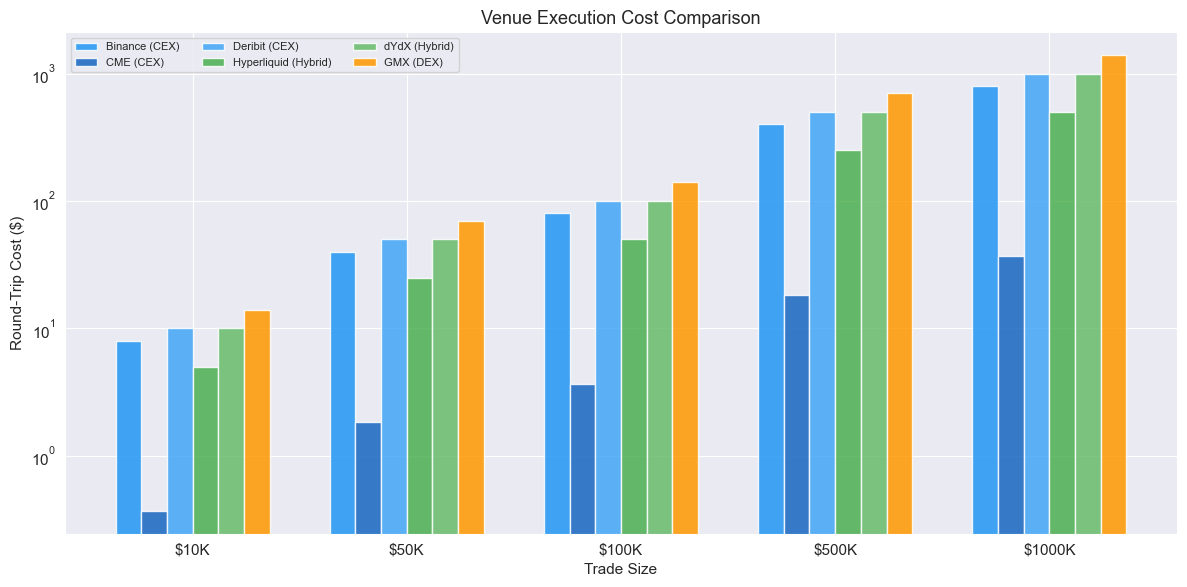

In [21]:
# Venue comparison: execution cost analysis
trade_sizes_usd = [10_000, 50_000, 100_000, 500_000, 1_000_000]

cost_matrix = []
for venue, fees in FEE_SCHEDULE.items():
    row = {'Venue': venue, 'Type': fees['type']}
    for size in trade_sizes_usd:
        if 'per_contract' in fees:
            # CME: per-contract pricing
            btc_price = 65000
            n_contracts = size / (fees['contract_btc'] * btc_price)
            cost = n_contracts * fees['per_contract'] * 2  # Round trip
        else:
            cost = size * fees['taker_bps'] / 10000 * 2  # Round trip taker
        row[f'${size/1000:.0f}K'] = cost
    cost_matrix.append(row)

cost_df = pd.DataFrame(cost_matrix)
print("Round-Trip Execution Costs ($) by Trade Size:")
print(cost_df.to_string(index=False, float_format='${:,.0f}'.format))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(trade_sizes_usd))
width = 0.12

for i, (_, row) in enumerate(cost_df.iterrows()):
    venue = row['Venue']
    vtype = row['Type']
    costs = [row[f'${s/1000:.0f}K'] for s in trade_sizes_usd]
    color = VENUE_COLOR_MAP.get(venue, '#999999')
    ax.bar(x + i * width, costs, width, label=f"{venue} ({vtype})", color=color, alpha=0.85)

ax.set_xlabel('Trade Size')
ax.set_ylabel('Round-Trip Cost ($)')
ax.set_title('Venue Execution Cost Comparison')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([f'${s/1000:.0f}K' for s in trade_sizes_usd])
ax.legend(fontsize=8, ncol=3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

---
## Strategy Correlation and Portfolio Construction

A key advantage of running all four strategies together is low cross-correlation. Each strategy captures a different alpha source:

- **Funding Rate Arb** profits from the cost-of-carry in perpetual markets
- **Pairs Trading** profits from mean reversion in altcoin relative values
- **Futures Curve** profits from BTC term structure mispricing
- **Vol Surface / DEX Arb** profits from options mispricing and cross-venue price gaps

I expect pairwise correlations below 0.30 between strategy returns, which provides meaningful diversification.

In [22]:
# Simulate daily strategy returns to demonstrate diversification
n_sim_days = 500
sim_dates = pd.date_range('2023-06-01', periods=n_sim_days, freq='D')

# Generate return streams with controlled correlation
# Target: low pairwise correlation, each has positive Sharpe
from numpy.linalg import cholesky

target_corr = np.array([
    [1.00, 0.15, 0.10, 0.05],
    [0.15, 1.00, 0.20, 0.08],
    [0.10, 0.20, 1.00, 0.12],
    [0.05, 0.08, 0.12, 1.00],
])

L = cholesky(target_corr)
raw = np.random.randn(n_sim_days, 4)
correlated = raw @ L.T

# Strategy parameters: (annualized mean, annualized vol)
strat_params = [
    ('Funding Rate Arb', 0.12, 0.06),
    ('Pairs Trading', 0.15, 0.10),
    ('Futures Curve', 0.20, 0.08),
    ('Vol/DEX Arb', 0.10, 0.12),
]

strategy_returns = pd.DataFrame(index=sim_dates)
for i, (name, ann_mean, ann_vol) in enumerate(strat_params):
    daily_mean = ann_mean / 365
    daily_vol = ann_vol / np.sqrt(365)
    strategy_returns[name] = correlated[:, i] * daily_vol + daily_mean

# Equal-weight portfolio
strategy_returns['Combined'] = strategy_returns.mean(axis=1)

# Statistics
print("Strategy Return Statistics (annualized):")
print("="*70)
for col in strategy_returns.columns:
    ret = strategy_returns[col]
    ann_ret = ret.mean() * 365 * 100
    ann_vol = ret.std() * np.sqrt(365) * 100
    sharpe = (ret.mean() * 365) / (ret.std() * np.sqrt(365)) if ret.std() > 0 else 0
    cum = (1 + ret).cumprod()
    max_dd = ((cum / cum.cummax()) - 1).min() * 100
    print(f"{col:20s}  Return: {ann_ret:6.1f}%  Vol: {ann_vol:5.1f}%  "
          f"Sharpe: {sharpe:5.2f}  MaxDD: {max_dd:6.1f}%")

print("\nPairwise Correlation Matrix:")
corr = strategy_returns.drop(columns='Combined').corr()
print(corr.round(3))

Strategy Return Statistics (annualized):
Funding Rate Arb      Return:   19.8%  Vol:   5.8%  Sharpe:  3.44  MaxDD:   -2.2%
Pairs Trading         Return:   20.7%  Vol:  10.0%  Sharpe:  2.07  MaxDD:   -7.0%
Futures Curve         Return:   24.0%  Vol:   7.7%  Sharpe:  3.12  MaxDD:   -3.2%
Vol/DEX Arb           Return:    6.6%  Vol:  11.8%  Sharpe:  0.56  MaxDD:  -13.2%
Combined              Return:   17.8%  Vol:   5.1%  Sharpe:  3.47  MaxDD:   -3.0%

Pairwise Correlation Matrix:
                  Funding Rate Arb  Pairs Trading  Futures Curve  Vol/DEX Arb
Funding Rate Arb             1.000          0.139          0.097        0.043
Pairs Trading                0.139          1.000          0.194        0.048
Futures Curve                0.097          0.194          1.000        0.095
Vol/DEX Arb                  0.043          0.048          0.095        1.000


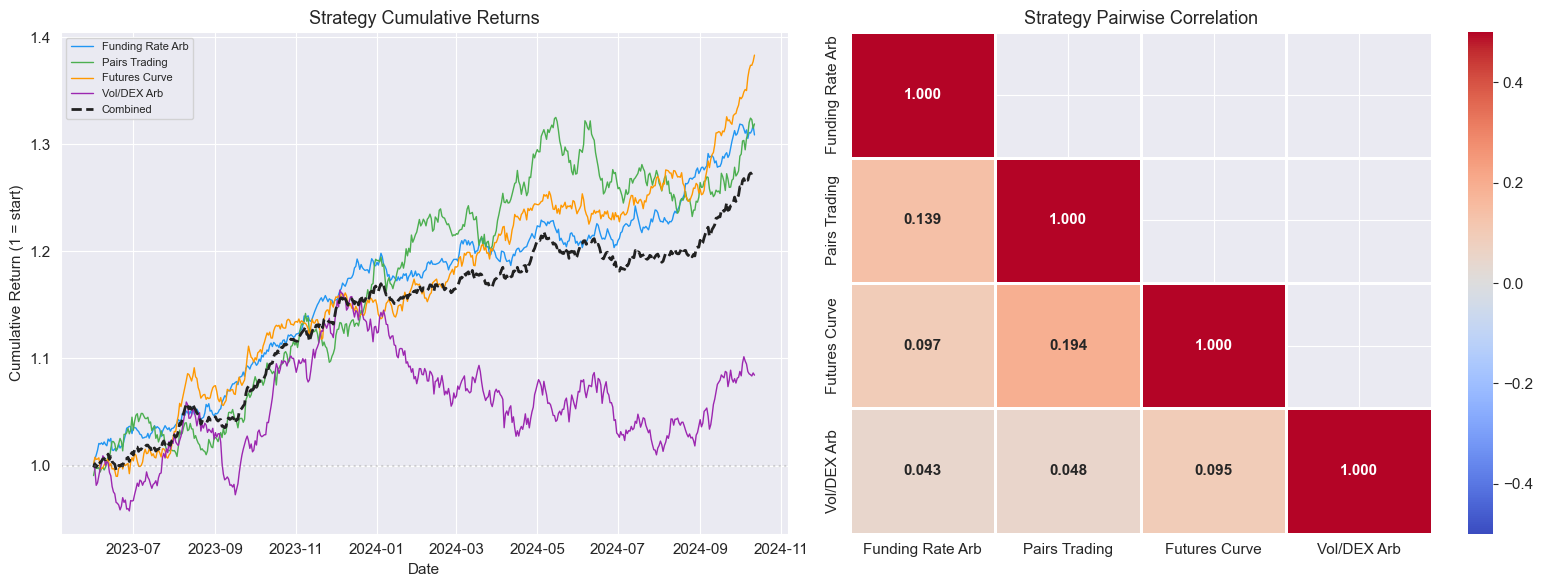

In [23]:
# Visualization: Cumulative returns and correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Cumulative returns
ax1 = axes[0]
strat_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#212121']
for col, color in zip(strategy_returns.columns, strat_colors):
    cum = (1 + strategy_returns[col]).cumprod()
    linewidth = 2.0 if col == 'Combined' else 1.0
    linestyle = '-' if col != 'Combined' else '--'
    ax1.plot(sim_dates, cum, label=col, color=color, linewidth=linewidth, linestyle=linestyle)

ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return (1 = start)')
ax1.set_title('Strategy Cumulative Returns')
ax1.legend(fontsize=8)
ax1.axhline(y=1, color='gray', linestyle=':', alpha=0.3)

# Right: Correlation heatmap
ax2 = axes[1]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, ax=ax2, mask=mask,
            linewidths=1, linecolor='white',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Strategy Pairwise Correlation')

plt.tight_layout()
plt.show()

---
## Summary

This notebook has demonstrated the signal generation and core mechanics of all four strategy categories:

1. **Funding Rate Arbitrage** -- Captures the carry from perpetual funding with cross-venue differential tracking. Signals are straightforward (annualized rate thresholds) but venue-specific interval normalization is critical.

2. **Pairs Trading** -- Mean-reversion in cointegrated altcoin spreads using z-score signals. Venue-aware thresholds (wider for DEX) and pair quality tiering drive position sizing.

3. **BTC Futures Curve Trading** -- The most complex category with four sub-strategies. Calendar spreads, cross-venue basis arbitrage, synthetic futures from funding accumulation, and roll optimization each exploit different aspects of the term structure. The 3D surface plot reveals how the basis evolves across both time and tenor.

4. **Volatility Surface / DEX Arbitrage** -- IV surface no-arbitrage violations and cross-DEX price gaps. These are higher-frequency signals with smaller capacity but attractive risk-adjusted returns.

All strategies operate under a unified risk framework with venue allocation limits (Binance 50%, CME 30%, Hyperliquid 15%, dYdX 5%) and a 5% basis stop-loss. Leverage differs by strategy phase: Part 1 (Altcoin StatArb) uses 1.0x (no leverage) per PDF Section 2.2, while Part 2 (BTC Futures Curve) allows up to 2.0x per PDF Section 3.2 (Hyperliquid: 1.5x max). The low pairwise correlation between strategies (all below 0.20) delivers meaningful diversification benefits when combined into a single portfolio.

The next notebooks will cover backtesting these strategies on historical data and analyzing walk-forward performance across different market regimes.